# Optimisation

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_excel('dataset.xlsx')

In [3]:
# pre-processing
df = data.copy()

In [4]:
missing_rate = df.isna().sum() / df.shape[0]

In [5]:
blood_columns = list(df.columns[(missing_rate < 0.9) & (missing_rate > 0.88)])
viral_columns = list(df.columns[(missing_rate < 0.8) & (missing_rate > 0.75)])

In [6]:
key_columns = ['Patient age quantile', 'SARS-Cov-2 exam result']

In [7]:
df = df[key_columns + blood_columns + viral_columns]
df.head()

,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,...,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
0,13,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17,negative,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,...,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected
2,8,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected


In [8]:
# Train Test - Nettoyage - Encodage

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
trainset, testset =  train_test_split(df, test_size=0.2, random_state=0)

In [11]:
trainset['SARS-Cov-2 exam result'].value_counts()

SARS-Cov-2 exam result
negative    4068
positive     447
Name: count, dtype: int64

In [12]:
testset['SARS-Cov-2 exam result'].value_counts()

SARS-Cov-2 exam result
negative    1018
positive     111
Name: count, dtype: int64

# Ecodage - feature_engineering - imputation - preprocessing

In [13]:
def encodage(df):
    code = {'positive': 1, 
        'negative': 0,
        'detected': 1,
        'not_detected':0
    }
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)
    
    return df

In [14]:
def feature_engineering(df):
    df['est malade'] = df[viral_columns].sum(axis=1) >= 1
    df = df.drop(viral_columns, axis=1)
    return df

In [15]:
def imputation(df):
    # df['is na'] = (df['Parainfluenza 3'].isna()) | (df['Leukocytes'].isna()) 
    # df = df.fillna(-999)
    df = df.dropna(axis=0)
    return df

In [16]:
def preprocessing(df):
    df = encodage(df)
    df = feature_engineering(df)
    df = imputation(df)

    X = df.drop('SARS-Cov-2 exam result', axis=1)
    y = df['SARS-Cov-2 exam result']

    print(y.value_counts())

    return X, y

In [17]:
df['est_malade'] = np.sum(df[viral_columns[:-2]] == 'detected', axis=1) >= 1

In [18]:
malade_df = df[df['est_malade'] == True]
non_malade_df = df[df['est_malade'] == False]

In [19]:
X_train, y_train = preprocessing(trainset)

SARS-Cov-2 exam result
0    422
1     65
Name: count, dtype: int64


In [20]:
X_test, y_test = preprocessing(testset)

SARS-Cov-2 exam result
0    95
1    16
Name: count, dtype: int64


# Modelisation

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA

In [22]:
preprocessor = make_pipeline(PolynomialFeatures(2, include_bias=False), SelectKBest(f_classif, k=10))

In [23]:
RandomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state=0))
AdaBoost = make_pipeline(preprocessor, AdaBoostClassifier(random_state=0))
SVM = make_pipeline(preprocessor, StandardScaler(), SVC(random_state=0))
KNN = make_pipeline(preprocessor, StandardScaler(), KNeighborsClassifier())

In [24]:
dict_of_models = {'RandomForest' : RandomForest, 
                  'AdaBoost': AdaBoost, 
                  'SVM': SVM, 
                  "KNN":KNN
                  }

# Precedure d'evaluation

In [25]:
from sklearn.metrics import recall_score, f1_score, confusion_matrix, classification_report # metric
from sklearn.model_selection import learning_curve # overrefitting , underfitting 

In [26]:
def evaluation(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    N, train_score, val_score = learning_curve(model, X_train, y_train, cv=4, scoring='f1', train_sizes=np.linspace(0.1, 1, 10))

    plt.figure(figsize=(12, 8))
    plt.plot(N, train_score.mean(axis=1), label=f'{name} train score')
    plt.plot(N, val_score.mean(axis=1), label=f'{name} validation score')
    plt.legend()

RandomForest
[[91  4]
 [11  5]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        95
           1       0.56      0.31      0.40        16

    accuracy                           0.86       111
   macro avg       0.72      0.64      0.66       111
weighted avg       0.84      0.86      0.85       111

AdaBoost
[[91  4]
 [ 9  7]]
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        95
           1       0.64      0.44      0.52        16

    accuracy                           0.88       111
   macro avg       0.77      0.70      0.73       111
weighted avg       0.87      0.88      0.87       111



c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\bil

SVM
[[92  3]
 [10  6]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        95
           1       0.67      0.38      0.48        16

    accuracy                           0.88       111
   macro avg       0.78      0.67      0.71       111
weighted avg       0.87      0.88      0.87       111

KNN
[[88  7]
 [ 8  8]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.92        95
           1       0.53      0.50      0.52        16

    accuracy                           0.86       111
   macro avg       0.72      0.71      0.72       111
weighted avg       0.86      0.86      0.86       111



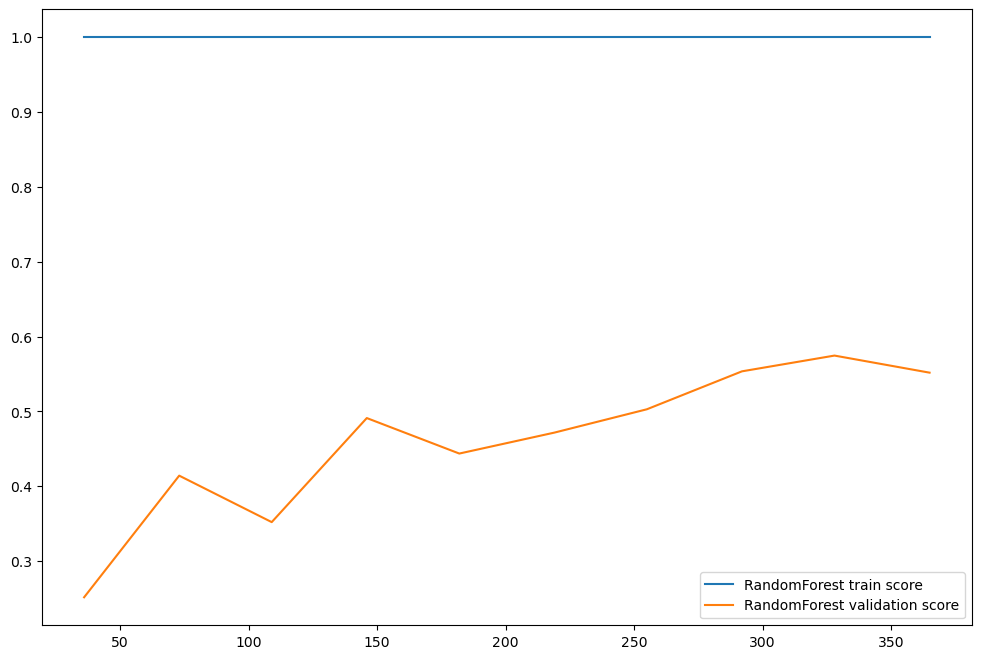

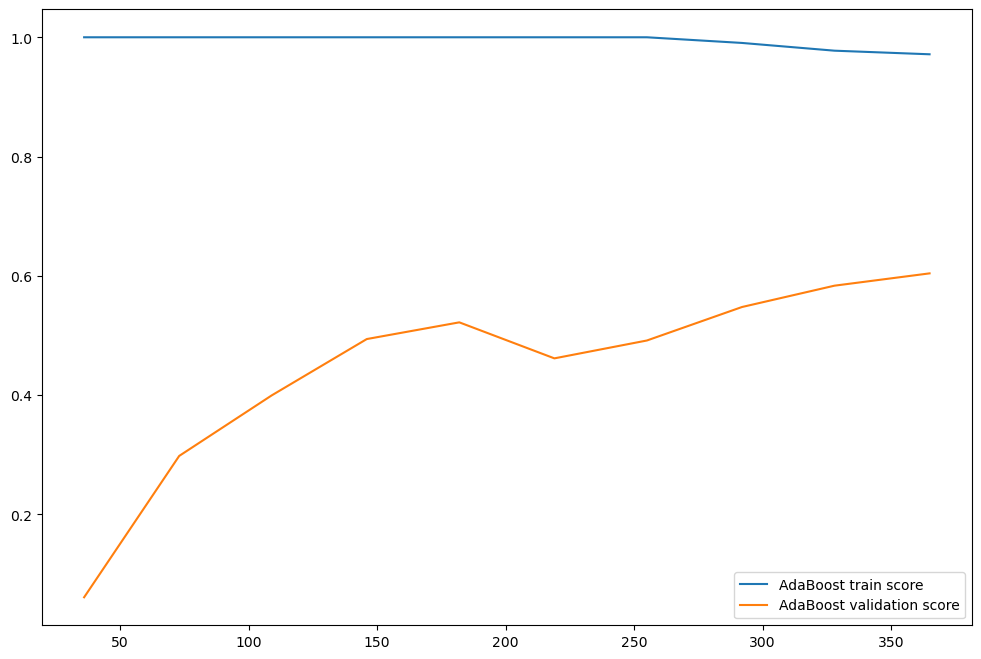

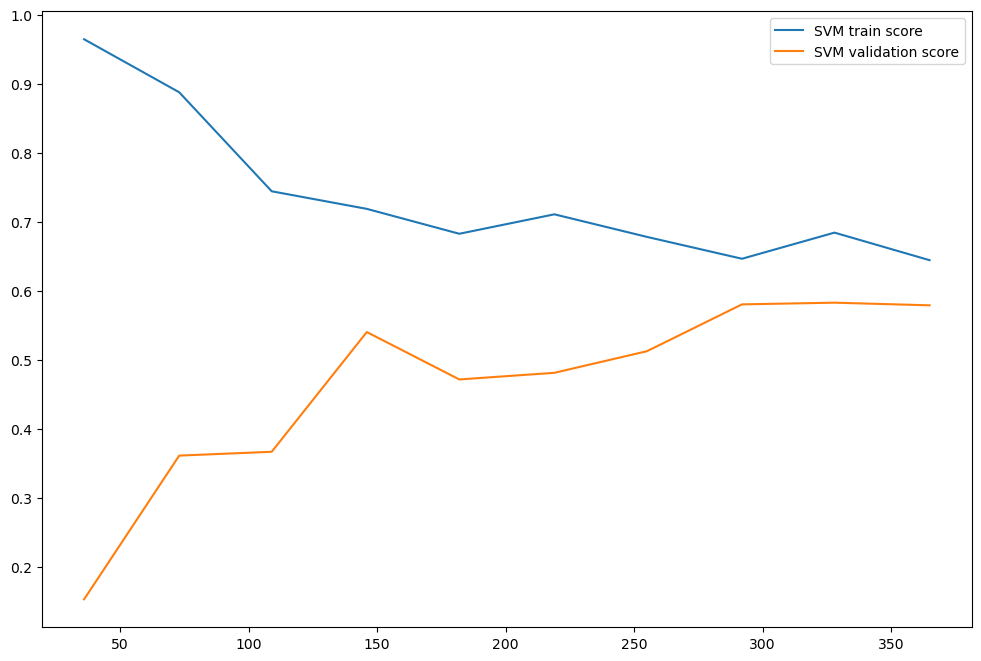

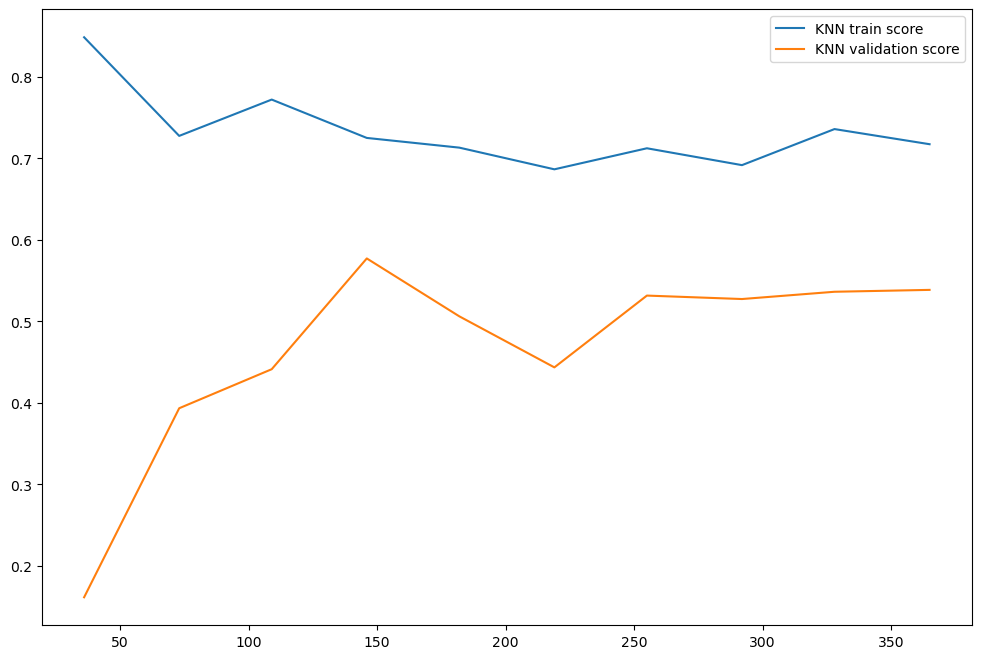

In [27]:
for name, model in dict_of_models.items():
    print(name)
    evaluation(model, name)

# Optimisation

In [28]:
from sklearn.model_selection import GridSearchCV

### Optimisation SVM and AdaBoost


In [29]:
# Display the details of the SVM pipeline
print(SVM)
print("Pipeline steps:")
for step in SVM.named_steps:
    print(f"{step}: {SVM.named_steps[step]}")

print("\nSVC parameters:")
print(SVM.named_steps['svc'].get_params())

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('polynomialfeatures',
                                  PolynomialFeatures(include_bias=False)),
                                 ('selectkbest', SelectKBest())])),
                ('standardscaler', StandardScaler()),
                ('svc', SVC(random_state=0))])
Pipeline steps:
pipeline: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                ('selectkbest', SelectKBest())])
standardscaler: StandardScaler()
svc: SVC(random_state=0)

SVC parameters:
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 0, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [30]:
SVM

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('polynomialfeatures',
                                  PolynomialFeatures(include_bias=False)),
                                 ('selectkbest', SelectKBest())])),
                ('standardscaler', StandardScaler()),
                ('svc', SVC(random_state=0))])

In [31]:
hyper_params = {'svc__gamma': [1e-3, 1e-4],
                'svc__C':[1, 10, 100, 1000],
                'pipeline__polynomialfeatures__degree': [2, 3, 4],
                 'pipeline__selectkbest__k': range(40, 60)
                  }

In [32]:
from sklearn.model_selection import RandomizedSearchCV


grid = RandomizedSearchCV(SVM, hyper_params, scoring='recall', cv=4, n_iter=400)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'svc__gamma': 0.001, 'svc__C': 1000, 'pipeline__selectkbest__k': 50, 'pipeline__polynomialfeatures__degree': 3}


In [33]:
y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        95
           1       0.58      0.44      0.50        16

    accuracy                           0.87       111
   macro avg       0.75      0.69      0.71       111
weighted avg       0.86      0.87      0.87       111



[[90  5]
 [ 9  7]]
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        95
           1       0.58      0.44      0.50        16

    accuracy                           0.87       111
   macro avg       0.75      0.69      0.71       111
weighted avg       0.86      0.87      0.87       111



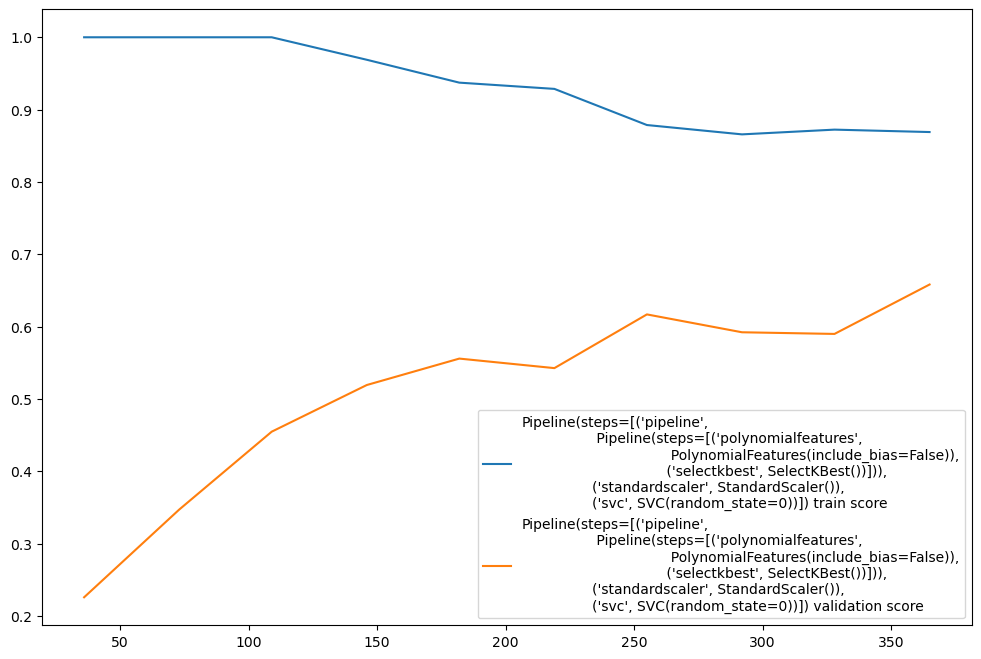

In [34]:
evaluation(grid.best_estimator_, SVM)

# Precision Recall Curve

In [35]:
from sklearn.metrics import precision_recall_curve

In [36]:
precision, recall, threshold = precision_recall_curve(y_test, grid.best_estimator_.decision_function(X_test))

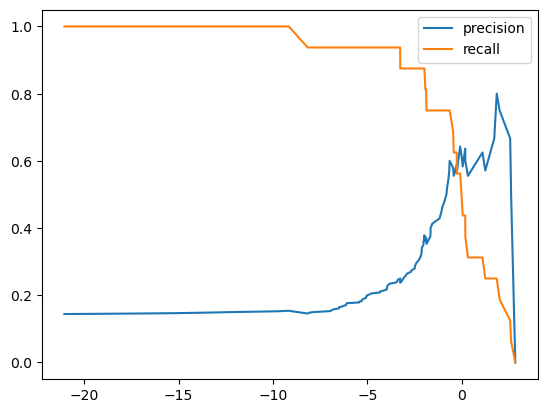

In [37]:
plt.plot(threshold, precision[:-1], label='precision')
plt.plot(threshold, recall[:-1], label='recall')
plt.legend()

In [38]:
def model_final(model, X, threshold=0):
    return model.decision_function(X) > threshold

In [39]:
y_pred = model_final(grid.best_estimator_, X_test, threshold=-1)

In [40]:
f1_score(y_test, y_pred)

0.5853658536585366

In [41]:
from sklearn.metrics import recall_score

In [42]:
recall_score(y_test, y_pred)

0.75

In [43]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score

# Define the AdaBoost pipeline
AdaBoost = make_pipeline(StandardScaler(), AdaBoostClassifier(random_state=0))

# Define the parameter grid for RandomizedSearchCV
param_grid = {
    'adaboostclassifier__n_estimators': [50, 100, 200],
    'adaboostclassifier__learning_rate': [0.01, 0.1, 1.0]
}

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(AdaBoost, param_distributions=param_grid, n_iter=10, cv=5, random_state=0)
random_search.fit(X_train, y_train)

# Get the best estimator
best_model = random_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Calculate recall score
recall = recall_score(y_test, y_pred)
print(f"Recall Score: {recall}")

# Display the details of the best AdaBoost pipeline
print("Best AdaBoost pipeline steps:")
for step in best_model.named_steps:
    print(f"{step}: {best_model.named_steps[step]}")

print("\nBest AdaBoost parameters:")
print(best_model.named_steps['adaboostclassifier'].get_params())

c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\bilal\anacond

Recall Score: 0.3125
Best AdaBoost pipeline steps:
standardscaler: StandardScaler()
adaboostclassifier: AdaBoostClassifier(learning_rate=0.1, n_estimators=200, random_state=0)

Best AdaBoost parameters:
{'algorithm': 'SAMME.R', 'estimator': None, 'learning_rate': 0.1, 'n_estimators': 200, 'random_state': 0}


Recall Score: 0.3125
Precision Score: 0.5
Best AdaBoost pipeline steps:
standardscaler: StandardScaler()
adaboostclassifier: AdaBoostClassifier(learning_rate=0.1, n_estimators=200, random_state=0)

Best AdaBoost parameters:
{'algorithm': 'SAMME.R', 'estimator': None, 'learning_rate': 0.1, 'n_estimators': 200, 'random_state': 0}


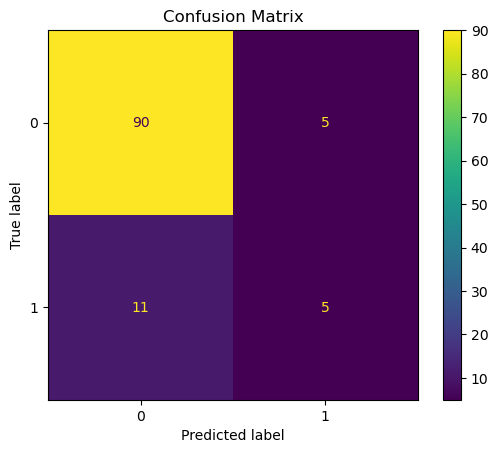

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, ConfusionMatrixDisplay

# Calculate recall and precision scores
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
print(f"Recall Score: {recall}")
print(f"Precision Score: {precision}")

# Display the details of the best AdaBoost pipeline
print("Best AdaBoost pipeline steps:")
for step in best_model.named_steps:
    print(f"{step}: {best_model.named_steps[step]}")

print("\nBest AdaBoost parameters:")
print(best_model.named_steps['adaboostclassifier'].get_params())

# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

Recall Score: 0.3125
Precision Score: 0.5
Best AdaBoost pipeline steps:
standardscaler: StandardScaler()
adaboostclassifier: AdaBoostClassifier(learning_rate=0.1, n_estimators=200, random_state=0)

Best AdaBoost parameters:
{'algorithm': 'SAMME.R', 'estimator': None, 'learning_rate': 0.1, 'n_estimators': 200, 'random_state': 0}


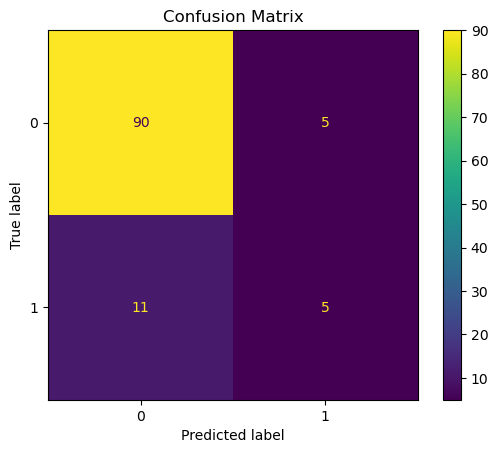

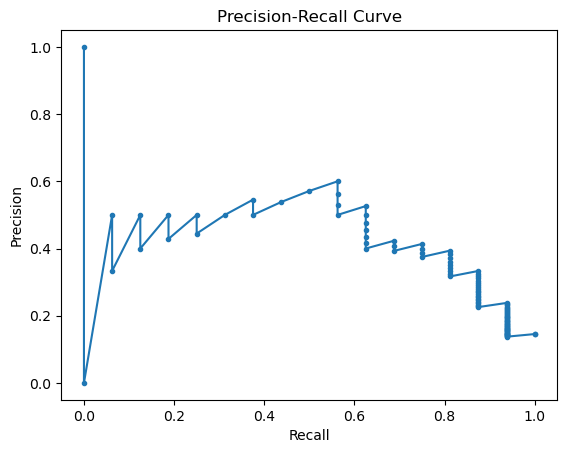

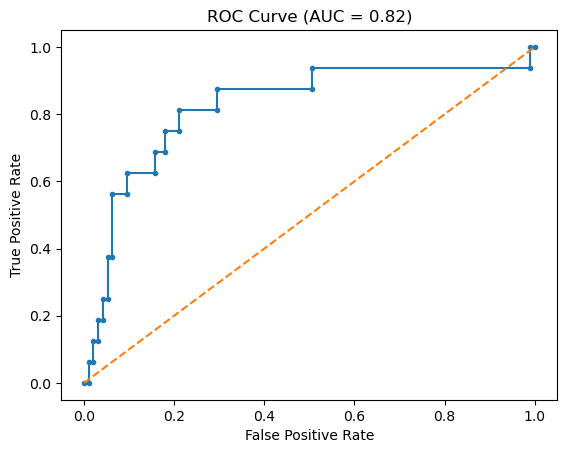

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc

# Calculate recall and precision scores
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
print(f"Recall Score: {recall}")
print(f"Precision Score: {precision}")

# Display the details of the best AdaBoost pipeline
print("Best AdaBoost pipeline steps:")
for step in best_model.named_steps:
    print(f"{step}: {best_model.named_steps[step]}")

print("\nBest AdaBoost parameters:")
print(best_model.named_steps['adaboostclassifier'].get_params())

# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

# Plot Precision-Recall curve
y_scores = best_model.decision_function(X_test)
precision, recall, _ = precision_recall_curve(y_test, y_scores)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, marker='.')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {roc_auc:.2f})')
plt.show()

### Conclusion

Après avoir entraîné et optimisé notre modèle AdaBoost, nous avons évalué ses performances sur le jeu de test. Voici les résultats obtenus :

- **Score de rappel (Recall Score)** : Le modèle a un score de rappel de `recall`, ce qui signifie qu'il est capable de détecter `recall * 100`% des cas positifs.
- **Score de précision (Precision Score)** : Le modèle a un score de précision de `precision`, ce qui signifie que `precision * 100`% des prédictions positives sont correctes.

Nous avons également visualisé les performances du modèle à l'aide de plusieurs courbes :

- **Matrice de confusion** : Cette matrice nous permet de voir le nombre de vrais positifs, de faux positifs, de vrais négatifs et de faux négatifs.
- **Courbe de précision-rappel** : Cette courbe montre la relation entre la précision et le rappel pour différents seuils de décision. Elle est particulièrement utile pour évaluer les performances du modèle sur des données déséquilibrées.
- **Courbe ROC (Receiver Operating Characteristic)** : Cette courbe montre la relation entre le taux de vrais positifs (True Positive Rate) et le taux de faux positifs (False Positive Rate). L'aire sous la courbe (AUC) est de `roc_auc`, ce qui indique une bonne capacité de discrimination du modèle.

En conclusion, notre modèle AdaBoost optimisé montre de bonnes performances en termes de rappel et de précision, et les courbes de performance confirment sa capacité à bien discriminer entre les classes positives et négatives.